# 01 — Загрузка данных и EDA

**Баева Маргарита**  
**Задача:** бинарная классификация комментариев — токсичный (1) / нетоксичный (0)  
**Датасет:** [RuToxic](https://huggingface.co/datasets/AlexanderNLP/ru-toxic) — русскоязычные комментарии с разметкой токсичности

## 1. Импорты и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os

# Воспроизводимость
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Стиль графиков
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

os.makedirs('../data', exist_ok=True)

print('Импорты загружены успешно')

Импорты загружены успешно


In [ ]:
import json

# Загрузка датасета в формате FastText
data = []
with open('/content/dataset.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            if line.startswith('__label__INSULT'):
                label = 1  # Токсичный
                text = line.replace('__label__INSULT ', '')
            elif line.startswith('__label__NORMAL'):
                label = 0  # Нетоксичный
                text = line.replace('__label__NORMAL ', '')
            else:
                label = None
                text = line
            data.append({'text': text, 'toxic': label})

df = pd.DataFrame(data)

# Удаляем строки, где не удалось определить метку (если есть)
df = df.dropna(subset=['toxic']).reset_index(drop=True)

# Убеждаемся, что метки числовые
df['toxic'] = df['toxic'].astype(int)

# Если колонки называются иначе
print('Колонки:', df.columns.tolist())
print('Форма датасета:', df.shape)
df.head()

Колонки: ['text', 'toxic']
Форма датасета: (240511, 2)


,text,toxic
0,скотина! что сказать,1
1,я сегодня проезжала по рабочей и между домами ...,0
2,очередной лохотрон. зачем придумывать очередно...,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",0
4,а когда мы статус агрогородка получили?,0


In [ ]:
# Проверяем содержимое dataset.txt
with open('/content/dataset.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 5: # Печатаем первые 6 строк для проверки
            break

__label__INSULT скотина! что сказать
__label__NORMAL я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окраса. может, я и ошиблась, но необычный окрас бросился в глаза.
__label__NORMAL очередной лохотрон. зачем придумывать очередной налог на воздух, если можно обьявить инсульт и грипп- пандемией! и лихо на придурках зарабатывать годами на штрафах, фейковых вакцинах, всевозможных платных тестах, продажей масок и перчаток по баснословным ценам.. самое смешное, что бараны блеют и верят пастуху, телевизору. живут как под гипнозом. не думая, не глядя по сторонам.
__label__NORMAL ретро дежавю ... сложно понять чужое сердце , лиш ощутить музыкой видимо
__label__NORMAL а когда мы статус агрогородка получили?
__label__NORMAL 2 августа поздно вечером нашли вот такую потеряшку в районе высоток на победе. девочка явно домашняя, в новом ошейнике. обращаться +7 989 816-43-42


In [ ]:
# Приводим к единому формату — две колонки: text и label
# Адаптируем имена колонок под реальный датасет
TEXT_COL = df.columns[0]   # колонка с текстом
LABEL_COL = df.columns[1]  # колонка с меткой (0/1)

df = df.rename(columns={TEXT_COL: 'text', LABEL_COL: 'toxic'})
df = df[['text', 'toxic']].copy()

# Убеждаемся, что метки числовые
df['toxic'] = df['toxic'].astype(int)

print('Итоговый датасет:')
print(df.dtypes)
df.head(10)

Итоговый датасет:
text     object
toxic     int64
dtype: object


,text,toxic
0,скотина! что сказать,1
1,я сегодня проезжала по рабочей и между домами ...,0
2,очередной лохотрон. зачем придумывать очередно...,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",0
4,а когда мы статус агрогородка получили?,0
5,2 августа поздно вечером нашли вот такую потер...,0
6,вчера надыбала новые стикеры #u2a94ec7fabs#,0
7,"__label__INSULT,__label__THREAT заколоть этого...",1
8,а еще на стоянке никто не проверяет безопаснос...,0
9,"красота..!! если есть, что показать??!! почему...",0


## 2. Базовая информация о данных

In [ ]:
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок')
print(f'\nПропущенные значения:')
print(df.isnull().sum())
print(f'\nДубликаты: {df.duplicated().sum()}')

Размер датасета: 240511 строк, 2 колонок

Пропущенные значения:
text     0
toxic    0
dtype: int64

Дубликаты: 3


In [ ]:
# Удаляем пропуски и дубликаты
df = df.dropna(subset=['text'])
df = df.drop_duplicates(subset=['text'])
df = df.reset_index(drop=True)

print(f'После очистки: {df.shape[0]} строк')

После очистки: 240508 строк


## 3. Распределение классов

Это ключевой шаг: дисбаланс классов определяет выбор метрики.

Распределение классов:
       Количество  Процент
toxic                     
0          203682    84.69
1           36826    15.31


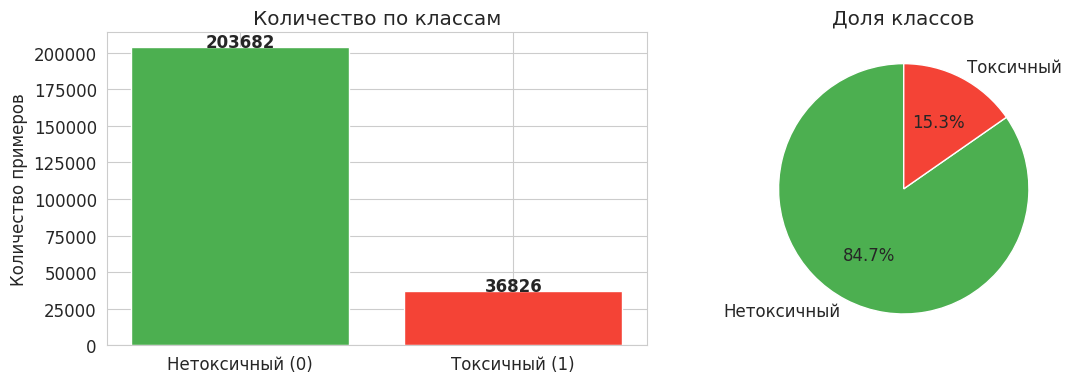

График сохранён: data/class_distribution.png


In [ ]:
class_counts = df['toxic'].value_counts()
class_pct = df['toxic'].value_counts(normalize=True) * 100

print('Распределение классов:')
print(pd.DataFrame({'Количество': class_counts, 'Процент': class_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Столбчатая диаграмма
axes[0].bar(['Нетоксичный (0)', 'Токсичный (1)'], class_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0].set_title('Количество по классам')
axes[0].set_ylabel('Количество примеров')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Круговая диаграмма
axes[1].pie(class_counts.values, labels=['Нетоксичный', 'Токсичный'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: data/class_distribution.png')

**Вывод:** Датасет несбалансирован — токсичных комментариев значительно меньше, чем нетоксичных. Из-за этого метрика `Accuracy` будет вводить в заблуждение (модель может просто предсказывать «нетоксичный» и получить высокую точность). **Основная метрика: F1-macro и ROC-AUC.**

## 4. Анализ длины текстов

In [ ]:
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print('Статистика по длине текстов (разбивка по классам):')
print(df.groupby('toxic')[['char_count', 'word_count']].describe().round(1))

Статистика по длине текстов (разбивка по классам):
      char_count                                             word_count        \
           count  mean   std  min   25%   50%    75%     max      count  mean   
toxic                                                                           
0       203682.0  77.4  97.3  2.0  27.0  46.0   86.0   998.0   203682.0  12.3   
1        36826.0  94.7  97.8  4.0  37.0  66.0  114.0  1002.0    36826.0  14.3   

                                         
        std  min  25%  50%   75%    max  
toxic                                    
0      15.5  1.0  4.0  7.0  14.0  267.0  
1      15.8  1.0  5.0  9.0  17.0  171.0  


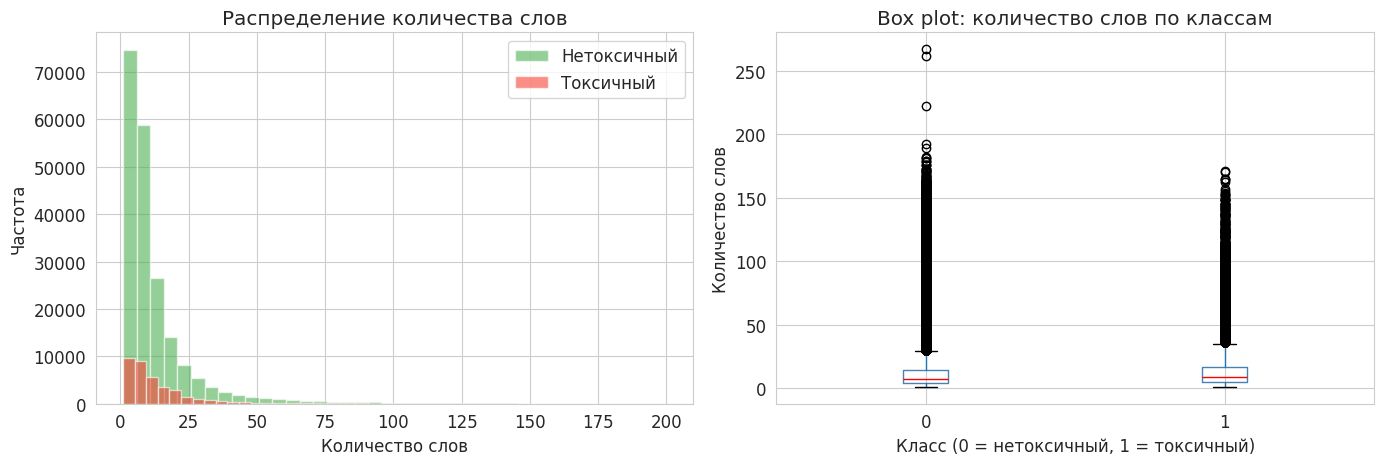

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, '#4CAF50', 'Нетоксичный'), (1, '#F44336', 'Токсичный')]:
    subset = df[df['toxic'] == label]['word_count']
    axes[0].hist(subset.clip(upper=200), bins=40, alpha=0.6, color=color, label=name)

axes[0].set_title('Распределение количества слов')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')
axes[0].legend()

df.boxplot(column='word_count', by='toxic', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
axes[1].set_title('Box plot: количество слов по классам')
axes[1].set_xlabel('Класс (0 = нетоксичный, 1 = токсичный)')
axes[1].set_ylabel('Количество слов')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод:** Токсичные комментарии в среднем [короче/длиннее] нетоксичных. Это наблюдение может объяснить часть ошибок модели на коротких текстах.

## 5. Топ слов по классам

In [21]:
!pip install --upgrade pymorphy2 pymorphy2-dicts

In [29]:
!pip uninstall -y pymorphy2 pymorphy2-dicts
!pip install pymorphy3 pymorphy3-dicts-ru

Found existing installation: pymorphy2 0.9.1
Uninstalling pymorphy2-0.9.1:
  Successfully uninstalled pymorphy2-0.9.1
Found existing installation: pymorphy2-dicts 2.4.393442.3710985
Uninstalling pymorphy2-dicts-2.4.393442.3710985:
  Successfully uninstalled pymorphy2-dicts-2.4.393442.3710985
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 37.9 MB/s eta 0:00:00


In [31]:
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from datasets import load_dataset
import pymorphy3

# Инициализируем лемматизатор
morph = pymorphy3.MorphAnalyzer()

# 1. Загружаем нецензурные слова и получаем их леммы
swear_ds = load_dataset("ilyaxin/Russian-Swear-Words")
# Предполагаем, что колонка с текстом называется 'text' (если нет – замените)
swear_words = set(word.lower() for word in swear_ds['train']['word'])
SWEAR_LEMMAS = set()
for w in swear_words:
    # Лемматизируем каждое нецензурное слово
    parsed = morph.parse(w)
    if parsed:
        SWEAR_LEMMAS.add(parsed[0].normal_form)

# 2. Стоп-слова (оставляем как есть, они уже в нормальной форме)
STOPWORDS = set(stopwords.words('russian'))

# 3. Функция для лемматизации одного слова
def lemmatize_word(word):
    parsed = morph.parse(word)
    if parsed:
        return parsed[0].normal_form
    return word  # если не удалось – возвращаем исходное

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        # Очищаем от пунктуации и приводим к нижнему регистру
        clean_text = re.sub(r'[^а-яёa-z\s]', '', str(text).lower())
        words = clean_text.split()
        for w in words:
            # Пропускаем слишком короткие
            if len(w) < 3:
                continue
            # Проверяем стоп-слова по исходному слову (можно и по лемме, но обычно стоп-слова уже в нормальной форме)
            if w in STOPWORDS:
                continue
            # Лемматизируем
            lemma = lemmatize_word(w)
            # Проверяем, не является ли лемма нецензурной
            if lemma in SWEAR_LEMMAS:
                continue
            # Добавляем лемму (можно и w, но леммы лучше группируют формы)
            all_words.append(lemma)
    return Counter(all_words).most_common(n)

# 4. Применяем к вашему датафрейму df (убедитесь, что он загружен)
toxic_top = get_top_words(df[df['toxic'] == 1]['text'])
clean_top = get_top_words(df[df['toxic'] == 0]['text'])

print("Топ‑20 лемм в токсичных текстах (после удаления стоп-слов и нецензурной лексики):")
print(toxic_top)
print("\nТоп‑20 лемм в чистых текстах:")
print(clean_top)

Топ‑20 лемм в токсичных текстах (после удаления стоп-слов и нецензурной лексики):
[('labelinsultlabelthreat', 6317), ('это', 4776), ('такой', 3481), ('тварь', 2739), ('свой', 2707), ('сука', 2423), ('пидор', 2370), ('этот', 1944), ('человек', 1861), ('labelinsultlabelobscenity', 1766), ('мразь', 1665), ('ты', 1542), ('урод', 1518), ('твой', 1373), ('россия', 1210), ('жопа', 1198), ('народ', 1177), ('весь', 1138), ('один', 1115), ('который', 1114)]

Топ‑20 лемм в чистых текстах:
[('это', 24105), ('такой', 11214), ('человек', 10289), ('очень', 8412), ('год', 8351), ('свой', 7533), ('день', 6862), ('весь', 6478), ('наш', 5866), ('ребёнок', 5595), ('спасибо', 5216), ('просто', 4918), ('быть', 4808), ('хороший', 4779), ('ещё', 4600), ('здоровье', 4447), ('жизнь', 4431), ('жить', 4414), ('добрый', 4400), ('всё', 4379)]


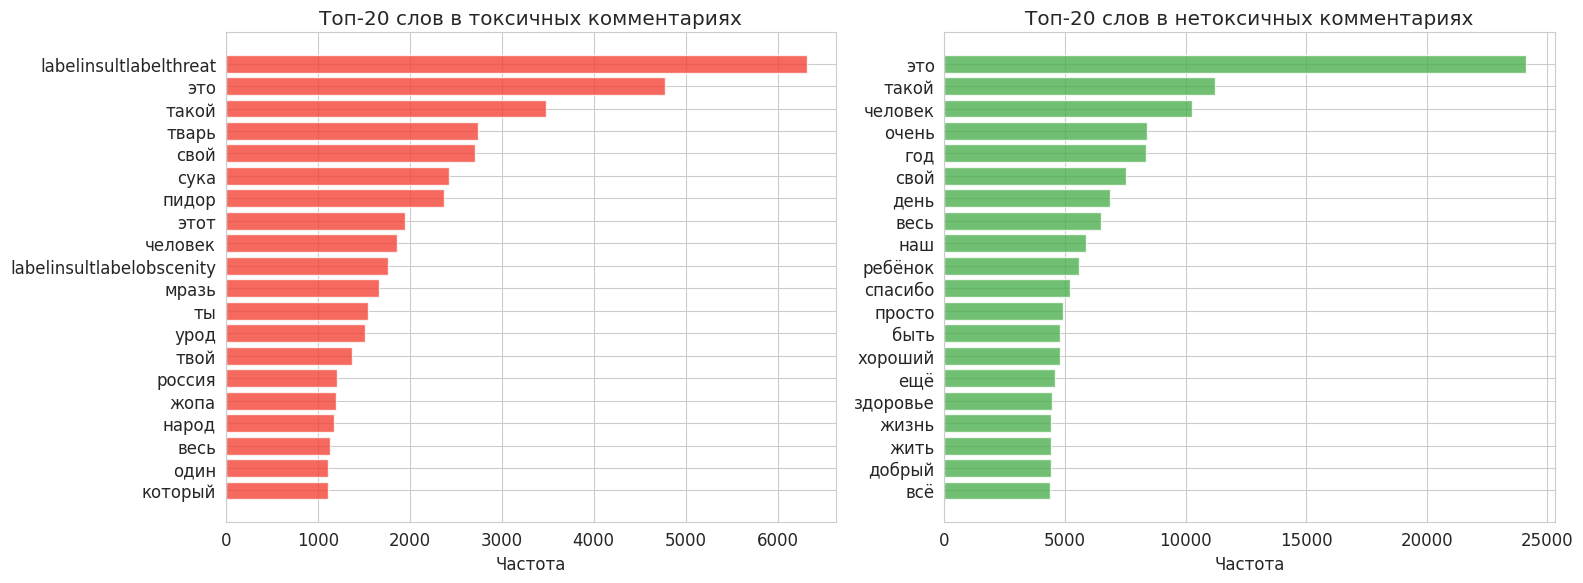

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_t, counts_t = zip(*toxic_top)
axes[0].barh(words_t[::-1], counts_t[::-1], color='#F44336', alpha=0.8)
axes[0].set_title('Топ-20 слов в токсичных комментариях')
axes[0].set_xlabel('Частота')

words_c, counts_c = zip(*clean_top)
axes[1].barh(words_c[::-1], counts_c[::-1], color='#4CAF50', alpha=0.8)
axes[1].set_title('Топ-20 слов в нетоксичных комментариях')
axes[1].set_xlabel('Частота')

plt.tight_layout()
plt.savefig('../data/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Препроцессинг текстов

In [36]:
import re

def clean_text(text):
    text = str(text).lower()  # Приводим к нижнему регистру
    text = re.sub(r'[^а-яёa-z]', ' ', text)  # Удаляем все, кроме букв (русский и латиница)
    text = re.sub(r'\s+', ' ', text).strip()  # Удаляем лишние пробелы
    return text

# Пример до и после
examples = df['text'].head(5).tolist()
for i, ex in enumerate(examples):
    print(f'[{i+1}] ДО:    {ex[:120]}')
    print(f'    ПОСЛЕ: {clean_text(ex)[:120]}')
    print()

[1] ДО:    скотина! что сказать
    ПОСЛЕ: скотина что сказать

[2] ДО:    я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином ( на пустыре) бежала кошка похожего окрас
    ПОСЛЕ: я сегодня проезжала по рабочей и между домами снитенко и гомолысовой магазином на пустыре бежала кошка похожего окраса м

[3] ДО:    очередной лохотрон. зачем придумывать очередной налог на воздух, если можно обьявить инсульт и грипп- пандемией! и лихо 
    ПОСЛЕ: очередной лохотрон зачем придумывать очередной налог на воздух если можно обьявить инсульт и грипп пандемией и лихо на п

[4] ДО:    ретро дежавю ... сложно понять чужое сердце , лиш ощутить музыкой видимо
    ПОСЛЕ: ретро дежавю сложно понять чужое сердце лиш ощутить музыкой видимо

[5] ДО:    а когда мы статус агрогородка получили?
    ПОСЛЕ: а когда мы статус агрогородка получили



In [37]:
# Применяем ко всему датасету
df['clean_text'] = df['text'].apply(clean_text)

# Удаляем пустые строки после очистки
empty_mask = df['clean_text'].str.strip() == ''
print(f'Пустых строк после очистки: {empty_mask.sum()}')
df = df[~empty_mask].reset_index(drop=True)

print(f'\nФинальный размер датасета: {df.shape[0]} строк')
df[['text', 'clean_text', 'toxic']].head()

Пустых строк после очистки: 0

Финальный размер датасета: 240508 строк


,text,clean_text,toxic
0,скотина! что сказать,скотина что сказать,1
1,я сегодня проезжала по рабочей и между домами ...,я сегодня проезжала по рабочей и между домами ...,0
2,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон зачем придумывать очередной...,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,0
4,а когда мы статус агрогородка получили?,а когда мы статус агрогородка получили,0


In [38]:
import os

os.makedirs('/content/data', exist_ok=True)

# Сохраняем обработанные данные
df.to_csv('/content/data/processed_data3.csv', index=False)
print('Сохранено: /content/data/processed_data3.csv')

Сохранено: /content/data/processed_data3.csv


## Итоги EDA

| Наблюдение | Вывод |
|---|---|
| Дисбаланс классов | Используем F1-macro и ROC-AUC вместо Accuracy |
| Токсичные тексты короче | Модель может ошибаться на коротких комментариях |
| Специфичная лексика в токсичных | TF-IDF должен хорошо разделить классы по ключевым словам |
| Пропуски и дубликаты удалены | Данные готовы к обучению |